In [ ]:
#Libraries that are needed for this assignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import stats,ttest_1samp, ttest_ind, ttest_rel, f_oneway, chi2_contingency

In [ ]:
#ID's from all CSV files that are linked and openly shared from Google Drive

Product_ID = '1R2kuJIraqI9zRVu2CBLiNv8fDoUjmH9o'
#https://drive.google.com/file/d/1R2kuJIraqI9zRVu2CBLiNv8fDoUjmH9o/view?usp=sharing
Supplier_Stock_Level_ID = '1WyNUuhXDCwnMKm4wo51YjTmYsXtH7Pxv'
#https://drive.google.com/file/d/1WyNUuhXDCwnMKm4wo51YjTmYsXtH7Pxv/view?usp=sharing
Transaction_ID = '1w4YsmieFroiwPAVethMmMDBaRzYKx0Oo'
#https://drive.google.com/file/d/1w4YsmieFroiwPAVethMmMDBaRzYKx0Oo/view?usp=sharing
Warehouse_ID = '16-MJXQ6Hr-XdF7ivxDfzgiK-IPcKFmy6'
#https://drive.google.com/file/d/16-MJXQ6Hr-XdF7ivxDfzgiK-IPcKFmy6/view?usp=sharing

In [ ]:
#Reading the CSV files with corresponding ID's

Product_Master_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={Product_ID}')
Supplier_Stock_Level_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={Supplier_Stock_Level_ID}')
Transaction_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={Transaction_ID}')
Warehouse_Info_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={Warehouse_ID}')

In [ ]:
#Finding NAN and duplicate values in Product_Master_df

print("Number of NAN values in Product_Master Dataframe: \n", Product_Master_df.isna().sum())
print("Number of Duplicated values in Product_Master Dataframe are",Product_Master_df.duplicated().sum())

Number of NAN values in Product_Master Dataframe: 
 product_id         0
category           0
product_name       0
perishable_flag    0
dtype: int64
Number of Duplicated values in Product_Master Dataframe are 0


In [ ]:
Product_Master_df.head(10)

,product_id,category,product_name,perishable_flag
0,P0001,Beverages,Dairy Item 1,0
1,P0002,Dairy,Bakery Item 2,1
2,P0003,Dairy,Frozen Item 3,1
3,P0004,Beverages,Dairy Item 4,0
4,P0005,Produce,Dairy Item 5,1
5,P0006,Bakery,Beverages Item 6,0
6,P0007,Bakery,Meat Item 7,0
7,P0008,Bakery,Dairy Item 8,0
8,P0009,Beverages,Frozen Item 9,0
9,P0010,Dairy,Bakery Item 10,1


In [ ]:
#Finding NAN and duplicate values in Supplier_Stock_Level_df

print("Number of NAN values in Supplier_Stock_Level Dataframe: \n", Supplier_Stock_Level_df.isna().sum())
print("Number of Duplicated values in Supplier_Stock_Level Dataframe are",Supplier_Stock_Level_df.duplicated().sum())

Number of NAN values in Supplier_Stock_Level Dataframe: 
 Product_Name    0
Supplier A      0
Supplier B      0
Supplier C      0
Supplier D      0
dtype: int64
Number of Duplicated values in Supplier_Stock_Level Dataframe are 0


In [ ]:
Supplier_Stock_Level_df.head(20)

,Product_Name,Supplier A,Supplier B,Supplier C,Supplier D
0,Blender,15,25,15,25
1,Cookware Set,21,21,22,22
2,Electric Toothbrush,25,22,23,19
3,Headphones,25,24,16,25
4,Jacket,15,19,19,19
5,Jeans,16,21,21,25
6,Laptop,24,17,19,19
7,Shampoo,22,20,23,20
8,Skincare Cream,22,21,25,20
9,Smartphone,25,23,16,24


In [ ]:
Supplier_Stock_Level_df.describe()

,Supplier A,Supplier B,Supplier C,Supplier D
count,16.000000,16.000000,16.000000,16.000000
mean,21.312500,21.062500,20.437500,20.312500
std,3.736643,2.909038,3.326034,3.004857
min,15.000000,15.000000,15.000000,16.000000
25%,18.750000,19.000000,18.250000,19.000000
50%,22.000000,21.000000,21.000000,19.000000
75%,25.000000,24.000000,23.000000,22.500000
max,25.000000,25.000000,25.000000,25.000000


In [ ]:
#Finding NAN and duplicate values in Transaction_df

print("Number of NAN values in Transaction Dataframe: \n", Transaction_df.isna().sum())
print("Number of Duplicated values in Transaction Dataframe are",Transaction_df.duplicated().sum())

Number of NAN values in Transaction Dataframe: 
 Transaction_ID         0
Date                   0
Region                 0
from_Warehouse         0
by_Supplier         6028
Product_Category       0
Product_Name           0
Units_Sold          9958
Unit_Price             0
dtype: int64
Number of Duplicated values in Transaction Dataframe are 0


In [ ]:
Transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644420 entries, 0 to 644419
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    644420 non-null  object 
 1   Date              644420 non-null  object 
 2   Region            644420 non-null  object 
 3   from_Warehouse    644420 non-null  object 
 4   by_Supplier       638392 non-null  object 
 5   Product_Category  644420 non-null  object 
 6   Product_Name      644420 non-null  object 
 7   Units_Sold        634462 non-null  float64
 8   Unit_Price        644420 non-null  float64
dtypes: float64(2), object(7)
memory usage: 44.2+ MB


In [ ]:
#Once identifying NAN and duplicate values, they were then dropped from data frame and data types were converted into correct corresponding types

Transaction_df.dropna(subset=['by_Supplier'],inplace=True)
Transaction_df.dropna(subset=['Product_Name'],inplace=True)
Transaction_df.dropna(subset=['Unit_Price'],inplace=True)
Transaction_df['Units_Sold'] = Transaction_df['Units_Sold'].fillna(Transaction_df['Units_Sold'].mean())
Transaction_df['Date'] = pd.to_datetime(Transaction_df['Date'], format='%d/%m/%Y')
print("Number of NAN values in Transaction Dataframe: \n", Transaction_df.isna().sum())
print("Number of Duplicated values in Transaction Dataframe are",Transaction_df.duplicated().sum())

Number of NAN values in Transaction Dataframe: 
 Transaction_ID      0
Date                0
Region              0
from_Warehouse      0
by_Supplier         0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
dtype: int64
Number of Duplicated values in Transaction Dataframe are 0


In [ ]:
Transaction_df['Units_Sold'] = Transaction_df['Units_Sold'].astype(int)
Transaction_df.head(10)

,Transaction_ID,Date,Region,from_Warehouse,by_Supplier,Product_Category,Product_Name,Units_Sold,Unit_Price
0,T000001,2024-01-27,Northern Europe,WH4,Supplier B,Home & Kitchen,Vacuum Cleaner,13,182.66
1,T000002,2024-03-19,Southern Europe,WH3,Supplier A,Home & Kitchen,Cookware Set,20,126.96
2,T000003,2024-02-27,Central Europe,WH2,Supplier A,Health & Beauty,Skincare Cream,20,34.21
3,T000004,2024-05-11,Central Europe,WH2,Supplier A,Home & Kitchen,Vacuum Cleaner,14,188.53
4,T000005,2024-02-26,Western Europe,WH1,Supplier B,Health & Beauty,Electric Toothbrush,21,64.02
5,T000006,2024-05-08,Northern Europe,WH4,Supplier A,Health & Beauty,Skincare Cream,17,36.38
6,T000007,2024-04-27,Central Europe,WH2,Supplier D,Clothing,Jacket,24,91.13
7,T000008,2024-04-28,Northern Europe,WH4,Supplier C,Clothing,T-shirt,19,18.77
8,T000009,2024-06-15,Western Europe,WH1,Supplier C,Health & Beauty,Vitamins,19,26.54
9,T000010,2024-06-12,Northern Europe,WH4,Supplier C,Electronics,Laptop,24,1375.33


In [ ]:
Transaction_df.describe()

,Date,Units_Sold,Unit_Price
count,638392,638392.000000,638392.000000
mean,2024-03-31 22:16:13.681373952,20.054648,221.916726
min,2024-01-01 00:00:00,7.000000,12.750000
25%,2024-02-15 00:00:00,17.000000,39.890000
50%,2024-04-03 00:00:00,20.000000,89.040000
75%,2024-05-17 00:00:00,23.000000,185.400000
max,2024-06-30 00:00:00,38.000000,1377.490000
std,NaN,4.439001,327.012989


In [ ]:
#Finding NAN and duplicate values in Warehouse_Info_df

print("Number of NAN values in Warehouse_Info Dataframe: \n", Warehouse_Info_df.isna().sum())
print("Number of Duplicated values in Warehouse_Info Dataframe are",Warehouse_Info_df.duplicated().sum())

Number of NAN values in Warehouse_Info Dataframe: 
 Warehouse             0
Warehouse_Capacity    0
Region                0
dtype: int64
Number of Duplicated values in Warehouse_Info Dataframe are 0


In [ ]:
Warehouse_Info_df.head(10)

,Warehouse,Warehouse_Capacity,Region
0,WH1,2870,Western Europe
1,WH2,2715,Central Europe
2,WH3,3000,Southern Europe
3,WH4,2902,Northern Europe


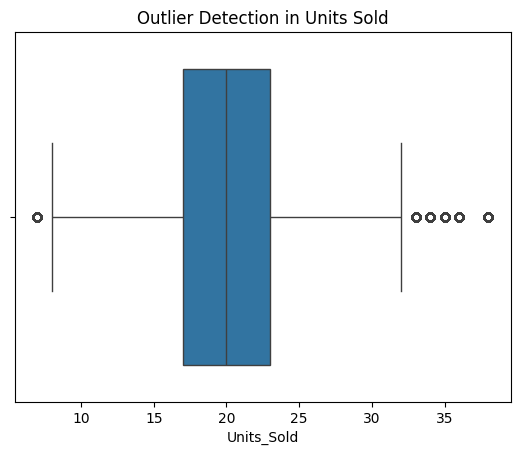

In [ ]:
#Outlier detection in Units_Sold

sns.boxplot(x=Transaction_df['Units_Sold'])
plt.title("Outlier Detection in Units Sold")
plt.show()

In [ ]:
#Dealing with outliers by IQR method

Quartile_1 = Transaction_df['Units_Sold'].quantile(0.25)
Quartile_3 = Transaction_df['Units_Sold'].quantile(0.75)
IQR = Quartile_3 - Quartile_1

Lower_bound = Quartile_1 - 1.5 * IQR
Upper_bound = Quartile_3 + 1.5 * IQR

iqr_outliers = Transaction_df[(Transaction_df['Units_Sold'] < Lower_bound) | (Transaction_df['Units_Sold'] > Upper_bound)]

print("IQR Outliers in Units Sold:")
print(iqr_outliers[['by_Supplier', 'Units_Sold']].count())

IQR Outliers in Units Sold:
by_Supplier    2667
Units_Sold     2667
dtype: int64


In [ ]:
#Taking all data thats within the lower and upper bounds

Transaction_df = Transaction_df[(Transaction_df['Units_Sold'] > Lower_bound) & (Transaction_df['Units_Sold'] < Upper_bound)]
Transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 632259 entries, 0 to 644419
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    632259 non-null  object        
 1   Date              632259 non-null  datetime64[ns]
 2   Region            632259 non-null  object        
 3   from_Warehouse    632259 non-null  object        
 4   by_Supplier       632259 non-null  object        
 5   Product_Category  632259 non-null  object        
 6   Product_Name      632259 non-null  object        
 7   Units_Sold        632259 non-null  int64         
 8   Unit_Price        632259 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 48.2+ MB


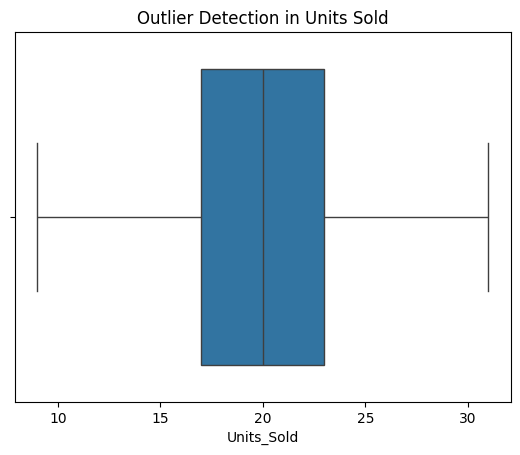

In [ ]:
#Checking if outliers have been removed

sns.boxplot(x=Transaction_df['Units_Sold'])
plt.title("Outlier Detection in Units Sold")
plt.show()

In [ ]:
Transaction_df.describe()

,Date,Units_Sold,Unit_Price
count,632259,632259.000000,632259.000000
mean,2024-03-31 20:39:34.548404992,19.990282,220.447503
min,2024-01-01 00:00:00,9.000000,12.750000
25%,2024-02-15 00:00:00,17.000000,39.760000
50%,2024-04-03 00:00:00,20.000000,88.760000
75%,2024-05-17 00:00:00,23.000000,183.720000
max,2024-06-30 00:00:00,31.000000,1377.490000
std,NaN,4.265534,325.505736


In [ ]:
#Feature engineering: Revenue and Month Columns

Transaction_df['Revenue'] = Transaction_df['Unit_Price'] * Transaction_df['Units_Sold']
Transaction_df['Month'] = Transaction_df['Date'].dt.to_period('M')
Transaction_df.head()

,Transaction_ID,Date,Region,from_Warehouse,by_Supplier,Product_Category,Product_Name,Units_Sold,Unit_Price,Revenue,Month
0,T000001,2024-01-27,Northern Europe,WH4,Supplier B,Home & Kitchen,Vacuum Cleaner,13,182.66,2374.58,2024-01
1,T000002,2024-03-19,Southern Europe,WH3,Supplier A,Home & Kitchen,Cookware Set,20,126.96,2539.20,2024-03
2,T000003,2024-02-27,Central Europe,WH2,Supplier A,Health & Beauty,Skincare Cream,20,34.21,684.20,2024-02
3,T000004,2024-05-11,Central Europe,WH2,Supplier A,Home & Kitchen,Vacuum Cleaner,14,188.53,2639.42,2024-05
4,T000005,2024-02-26,Western Europe,WH1,Supplier B,Health & Beauty,Electric Toothbrush,21,64.02,1344.42,2024-02


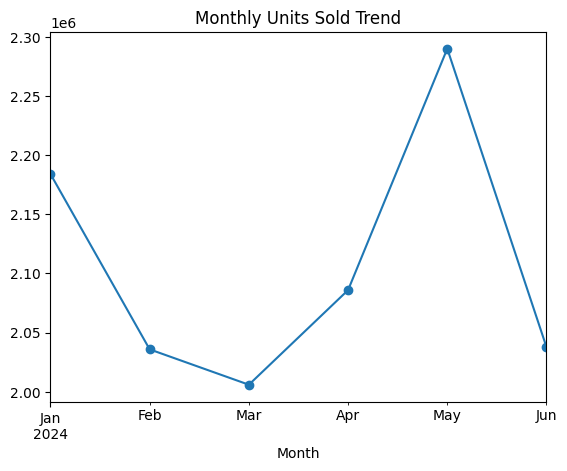

In [ ]:
#Sum of Units_Sold every month in all regions combined

Sales_by_Month = Transaction_df.groupby('Month')['Units_Sold'].sum()
Sales_by_Month.plot(title="Monthly Units Sold Trend", marker='o')
plt.show()

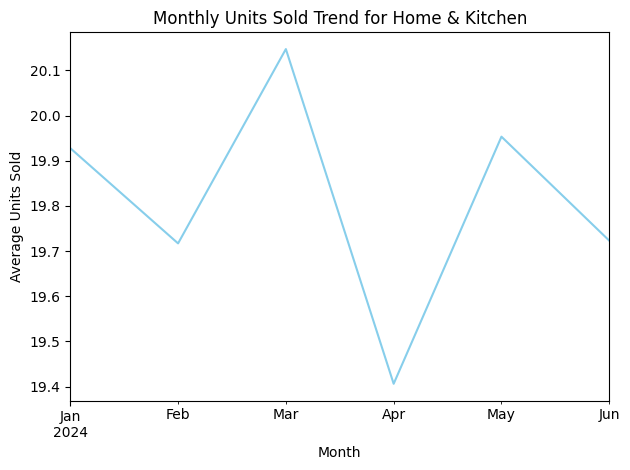

IndexingError: Too many indexers

In [ ]:
Sales_category = Transaction_df.groupby(['Month','Product_Category'])['Units_Sold'].mean()

category = 'Home & Kitchen'
Sales_category = Sales_category.loc[(slice(None), category)]

Sales_category.plot(kind='line', title=f"Monthly Units Sold Trend for {category}", color='skyblue')
plt.ylabel('Average Units Sold')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
print()

category_2 = 'Health & Beauty'
Sales_category = Sales_category.loc[(slice(None), category_2)]

Sales_category.plot(kind='line', title=f"Monthly Units Sold Trend for {category_2}", color='skyblue')
plt.ylabel('Average Units Sold')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
print()

category_3 = 'Electronics'
Sales_category = Sales_category.loc[(slice(None), category_3)]

Sales_category.plot(kind='line', title=f"Monthly Units Sold Trend for {category_3}", color='skyblue')
plt.ylabel('Average Units Sold')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
print()

category_4 = 'Clothing'
Sales_category = Sales_category.loc[(slice(None), category_4)]

Sales_category.plot(kind='line', title=f"Monthly Units Sold Trend for {category_4}", color='skyblue')
plt.ylabel('Average Units Sold')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [ ]:
#Sorting dates in order on the transaction data frame

Transaction_df = Transaction_df.sort_values(by='Date',ascending=True)
Transaction_df = Transaction_df.reset_index()
Transaction_df.head()

,index,Transaction_ID,Date,Region,from_Warehouse,by_Supplier,Product_Category,Product_Name,Units_Sold,Unit_Price,Revenue,Month
0,418452,T418453,2024-01-01,Northern Europe,WH4,Supplier A,Health & Beauty,Vitamins,21,23.44,492.24,2024-01
1,459046,T459047,2024-01-01,Southern Europe,WH3,Supplier B,Health & Beauty,Shampoo,20,14.02,280.40,2024-01
2,158764,T158765,2024-01-01,Northern Europe,WH4,Supplier B,Electronics,Tablet,26,423.76,11017.76,2024-01
3,116499,T116500,2024-01-01,Central Europe,WH2,Supplier B,Electronics,Headphones,17,135.26,2299.42,2024-01
4,459278,T459279,2024-01-01,Northern Europe,WH4,Supplier A,Health & Beauty,Vitamins,21,26.01,546.21,2024-01


In [ ]:
#Product Stockout Date Finder for Supplier A

Blender = Transaction_df[Transaction_df['Product_Name'] == 'Blender']
blend_supp_a = Blender[Blender['by_Supplier'] == 'Supplier A'].reset_index()
Cookware = Transaction_df[Transaction_df['Product_Name'] == 'Cookware Set']
cook_supp_a = Cookware[Cookware['by_Supplier'] == 'Supplier A'].reset_index()
Toothbrush = Transaction_df[Transaction_df['Product_Name'] == 'Electric Toothbrush']
tooth_supp_a = Toothbrush[Toothbrush['by_Supplier'] == 'Supplier A'].reset_index()
Headphones = Transaction_df[Transaction_df['Product_Name'] == 'Headphones']
hp_supp_a = Headphones[Headphones['by_Supplier'] == 'Supplier A'].reset_index()
Jacket = Transaction_df[Transaction_df['Product_Name'] == 'Jacket']
jacket_supp_a = Jacket[Jacket['by_Supplier'] == 'Supplier A'].reset_index()
Jeans = Transaction_df[Transaction_df['Product_Name'] == 'Jeans']
jeans_supp_a = Jeans[Jeans['by_Supplier'] == 'Supplier A'].reset_index()
Laptop = Transaction_df[Transaction_df['Product_Name'] == 'Laptop']
laptop_supp_a = Laptop[Laptop['by_Supplier'] == 'Supplier A'].reset_index()
Shampoo = Transaction_df[Transaction_df['Product_Name'] == 'Shampoo']
shamp_supp_a = Shampoo[Shampoo['by_Supplier'] == 'Supplier A'].reset_index()
Skincare = Transaction_df[Transaction_df['Product_Name'] == 'Skincare Cream']
skin_supp_a = Skincare[Skincare['by_Supplier'] == 'Supplier A'].reset_index()
Smartphone = Transaction_df[Transaction_df['Product_Name'] == 'Smartphone']
phone_supp_a = Smartphone[Smartphone['by_Supplier'] == 'Supplier A'].reset_index()
Sneakers = Transaction_df[Transaction_df['Product_Name'] == 'Sneakers']
sneakers_supp_a = Sneakers[Sneakers['by_Supplier'] == 'Supplier A'].reset_index()
Tshirt = Transaction_df[Transaction_df['Product_Name'] == 'T-shirt']
shirt_supp_a = Tshirt[Tshirt['by_Supplier'] == 'Supplier A'].reset_index()
Tablet = Transaction_df[Transaction_df['Product_Name'] == 'Tablet']
tablet_supp_a = Tablet[Tablet['by_Supplier'] == 'Supplier A'].reset_index()
Toaster = Transaction_df[Transaction_df['Product_Name'] == 'Toaster']
toast_supp_a = Toaster[Toaster['by_Supplier'] == 'Supplier A'].reset_index()
Vacuum = Transaction_df[Transaction_df['Product_Name'] == 'Vacuum Cleaner']
vac_supp_a = Vacuum[Vacuum['by_Supplier'] == 'Supplier A'].reset_index()
Vitamin = Transaction_df[Transaction_df['Product_Name'] == 'Vitamins']
vitamin_supp_a = Vitamin[Vitamin['by_Supplier'] == 'Supplier A'].reset_index()


print("=========================")
print("Supplier A Stockout Date")
print(Supplier_Stock_Level_df['Product_Name'])
print("=========================")
print()

Finder_Input = int(input("Please Select a number correlating to the product you want information about: "))
print()

if Finder_Input == 0:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = blend_supp_a['index'].count()
  Length = index.max() + 1

  Input = blend_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input, Supplier]:
      print("There are a total number orders of: ", int(Total), " Blenders\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Blenders")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 1:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = cook_supp_a['index'].count()
  Length = index.max() + 1

  Input = cook_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Cookware Sets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Cookware Sets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 2:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tooth_supp_a['index'].count()
  Length = index.max() + 1

  Input = tooth_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Electric Toothbrushes\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Electric Toothbrushes")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 3:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = hp_supp_a['index'].count()
  Length = index.max() + 1

  Input = hp_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Headphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Headphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 4:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jacket_supp_a['index'].count()
  Length = index.max() + 1

  Input = jacket_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jacket\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jacket")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 5:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jeans_supp_a['index'].count()
  Length = index.max() + 1

  Input = jeans_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jeans\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jeans")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 6:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = laptop_supp_a['index'].count()
  Length = index.max() + 1

  Input = laptop_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Laptop\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Laptop")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 7:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shamp_supp_a['index'].count()
  Length = index.max() + 1

  Input = shamp_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Shampoo\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Shampoo")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 8:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = skin_supp_a['index'].count()
  Length = index.max() + 1

  Input = skin_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Skincare Cream\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Skincare Cream")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 9:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = phone_supp_a['index'].count()
  Length = index.max() + 1

  Input = phone_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Smartphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Smartphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 10:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = sneakers_supp_a['index'].count()
  Length = index.max() + 1

  Input = sneakers_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Sneakers\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Sneakers")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 11:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shirt_supp_a['index'].count()
  Length = index.max() + 1

  Input = shirt_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "T-shirts\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "T-shirts")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 12:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tablet_supp_a['index'].count()
  Length = index.max() + 1

  Input = tablet_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Tablets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Tablets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 13:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = toast_supp_a['index'].count()
  Length = index.max() + 1

  Input = toast_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Toasters\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Toasters")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 14:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vac_supp_a['index'].count()
  Length = index.max() + 1

  Input = vac_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vacuum Cleaners\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vacuum Cleaners")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 15:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vitamin_supp_a['index'].count()
  Length = index.max() + 1

  Input = vitamin_supp_a
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vitamin product\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vitamin product")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      Total+=Combo
      b_variable+=1
      c_variable+=1

if Finder_Input > 15:
  print("Please rerun code and type a number in the the range of 0-15")



Supplier A Stockout Date
0                 Blender
1            Cookware Set
2     Electric Toothbrush
3              Headphones
4                  Jacket
5                   Jeans
6                  Laptop
7                 Shampoo
8          Skincare Cream
9              Smartphone
10               Sneakers
11                T-shirt
12                 Tablet
13                Toaster
14         Vacuum Cleaner
15               Vitamins
Name: Product_Name, dtype: object

Please Select a number correlating to the product you want information about: 9

There are a total number orders of:  56 Smartphones
Total number of available product is:  25 Smartphones

Stockout on: 
 Date              2024-01-01 00:00:00
from_Warehouse                    WH1
Region                 Western Europe
Name: 2, dtype: object


In [ ]:
#Product Stockout Date Finder for Supplier B

Blender = Transaction_df[Transaction_df['Product_Name'] == 'Blender']
blend_supp_b = Blender[Blender['by_Supplier'] == 'Supplier B'].reset_index()
Cookware = Transaction_df[Transaction_df['Product_Name'] == 'Cookware Set']
cook_supp_b = Cookware[Cookware['by_Supplier'] == 'Supplier B'].reset_index()
Toothbrush = Transaction_df[Transaction_df['Product_Name'] == 'Electric Toothbrush']
tooth_supp_b = Toothbrush[Toothbrush['by_Supplier'] == 'Supplier B'].reset_index()
Headphones = Transaction_df[Transaction_df['Product_Name'] == 'Headphones']
hp_supp_b = Headphones[Headphones['by_Supplier'] == 'Supplier B'].reset_index()
Jacket = Transaction_df[Transaction_df['Product_Name'] == 'Jacket']
jacket_supp_b = Jacket[Jacket['by_Supplier'] == 'Supplier B'].reset_index()
Jeans = Transaction_df[Transaction_df['Product_Name'] == 'Jeans']
jeans_supp_b = Jeans[Jeans['by_Supplier'] == 'Supplier B'].reset_index()
Laptop = Transaction_df[Transaction_df['Product_Name'] == 'Laptop']
laptop_supp_b = Laptop[Laptop['by_Supplier'] == 'Supplier B'].reset_index()
Shampoo = Transaction_df[Transaction_df['Product_Name'] == 'Shampoo']
shamp_supp_b = Shampoo[Shampoo['by_Supplier'] == 'Supplier B'].reset_index()
Skincare = Transaction_df[Transaction_df['Product_Name'] == 'Skincare Cream']
skin_supp_b = Skincare[Skincare['by_Supplier'] == 'Supplier B'].reset_index()
Smartphone = Transaction_df[Transaction_df['Product_Name'] == 'Smartphone']
phone_supp_b = Smartphone[Smartphone['by_Supplier'] == 'Supplier B'].reset_index()
Sneakers = Transaction_df[Transaction_df['Product_Name'] == 'Sneakers']
sneakers_supp_b = Sneakers[Sneakers['by_Supplier'] == 'Supplier B'].reset_index()
Tshirt = Transaction_df[Transaction_df['Product_Name'] == 'T-shirt']
shirt_supp_b = Tshirt[Tshirt['by_Supplier'] == 'Supplier B'].reset_index()
Tablet = Transaction_df[Transaction_df['Product_Name'] == 'Tablet']
tablet_supp_b = Tablet[Tablet['by_Supplier'] == 'Supplier B'].reset_index()
Toaster = Transaction_df[Transaction_df['Product_Name'] == 'Toaster']
toast_supp_b = Toaster[Toaster['by_Supplier'] == 'Supplier B'].reset_index()
Vacuum = Transaction_df[Transaction_df['Product_Name'] == 'Vacuum Cleaner']
vac_supp_b = Vacuum[Vacuum['by_Supplier'] == 'Supplier B'].reset_index()
Vitamin = Transaction_df[Transaction_df['Product_Name'] == 'Vitamins']
vitamin_supp_b = Vitamin[Vitamin['by_Supplier'] == 'Supplier B'].reset_index()


print("=========================")
print("Supplier B Stockout Date")
print(Supplier_Stock_Level_df['Product_Name'])
print("=========================")
print()

Finder_Input = int(input("Please Select a number correlating to the product you want information about: "))
print()

if Finder_Input == 0:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = blend_supp_b['index'].count()
  Length = index.max() + 1

  Input = blend_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input, Supplier]:
      print("There are a total number orders of: ", int(Total), " Blenders\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Blenders")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 1:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = cook_supp_b['index'].count()
  Length = index.max() + 1

  Input = cook_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Cookware Sets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Cookware Sets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 2:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tooth_supp_b['index'].count()
  Length = index.max() + 1

  Input = tooth_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Electric Toothbrushes\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Electric Toothbrushes")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 3:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = hp_supp_b['index'].count()
  Length = index.max() + 1

  Input = hp_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Headphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Headphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 4:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jacket_supp_b['index'].count()
  Length = index.max() + 1

  Input = jacket_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jacket\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jacket")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 5:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jeans_supp_b['index'].count()
  Length = index.max() + 1

  Input = jeans_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jeans\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jeans")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 6:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = laptop_supp_b['index'].count()
  Length = index.max() + 1

  Input = laptop_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Laptop\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Laptop")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 7:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shamp_supp_b['index'].count()
  Length = index.max() + 1

  Input = shamp_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Shampoo\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Shampoo")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 8:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = skin_supp_b['index'].count()
  Length = index.max() + 1

  Input = skin_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Skincare Cream\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Skincare Cream")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 9:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = phone_supp_b['index'].count()
  Length = index.max() + 1

  Input = phone_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Smartphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Smartphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 10:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = sneakers_supp_b['index'].count()
  Length = index.max() + 1

  Input = sneakers_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Sneakers\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Sneakers")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 11:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shirt_supp_b['index'].count()
  Length = index.max() + 1

  Input = shirt_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "T-shirts\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "T-shirts")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 12:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tablet_supp_b['index'].count()
  Length = index.max() + 1

  Input = tablet_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Tablets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Tablets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 13:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = toast_supp_b['index'].count()
  Length = index.max() + 1

  Input = toast_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Toasters\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Toasters")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 14:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vac_supp_b['index'].count()
  Length = index.max() + 1

  Input = vac_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vacuum Cleaners\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vacuum Cleaners")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 15:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vitamin_supp_b['index'].count()
  Length = index.max() + 1

  Input = vitamin_supp_b
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vitamin product\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vitamin product")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      Total+=Combo
      b_variable+=1
      c_variable+=1

if Finder_Input > 15:
  print("Please rerun code and type a number in the the range of 0-15")


In [ ]:
#Product Stockout Date Finder for Supplier C

Blender = Transaction_df[Transaction_df['Product_Name'] == 'Blender']
blend_supp_c = Blender[Blender['by_Supplier'] == 'Supplier C'].reset_index()
Cookware = Transaction_df[Transaction_df['Product_Name'] == 'Cookware Set']
cook_supp_c = Cookware[Cookware['by_Supplier'] == 'Supplier C'].reset_index()
Toothbrush = Transaction_df[Transaction_df['Product_Name'] == 'Electric Toothbrush']
tooth_supp_c = Toothbrush[Toothbrush['by_Supplier'] == 'Supplier C'].reset_index()
Headphones = Transaction_df[Transaction_df['Product_Name'] == 'Headphones']
hp_supp_c = Headphones[Headphones['by_Supplier'] == 'Supplier C'].reset_index()
Jacket = Transaction_df[Transaction_df['Product_Name'] == 'Jacket']
jacket_supp_c = Jacket[Jacket['by_Supplier'] == 'Supplier C'].reset_index()
Jeans = Transaction_df[Transaction_df['Product_Name'] == 'Jeans']
jeans_supp_c = Jeans[Jeans['by_Supplier'] == 'Supplier C'].reset_index()
Laptop = Transaction_df[Transaction_df['Product_Name'] == 'Laptop']
laptop_supp_c = Laptop[Laptop['by_Supplier'] == 'Supplier C'].reset_index()
Shampoo = Transaction_df[Transaction_df['Product_Name'] == 'Shampoo']
shamp_supp_c = Shampoo[Shampoo['by_Supplier'] == 'Supplier C'].reset_index()
Skincare = Transaction_df[Transaction_df['Product_Name'] == 'Skincare Cream']
skin_supp_c = Skincare[Skincare['by_Supplier'] == 'Supplier C'].reset_index()
Smartphone = Transaction_df[Transaction_df['Product_Name'] == 'Smartphone']
phone_supp_c = Smartphone[Smartphone['by_Supplier'] == 'Supplier C'].reset_index()
Sneakers = Transaction_df[Transaction_df['Product_Name'] == 'Sneakers']
sneakers_supp_c = Sneakers[Sneakers['by_Supplier'] == 'Supplier C'].reset_index()
Tshirt = Transaction_df[Transaction_df['Product_Name'] == 'T-shirt']
shirt_supp_c = Tshirt[Tshirt['by_Supplier'] == 'Supplier C'].reset_index()
Tablet = Transaction_df[Transaction_df['Product_Name'] == 'Tablet']
tablet_supp_c = Tablet[Tablet['by_Supplier'] == 'Supplier C'].reset_index()
Toaster = Transaction_df[Transaction_df['Product_Name'] == 'Toaster']
toast_supp_c = Toaster[Toaster['by_Supplier'] == 'Supplier C'].reset_index()
Vacuum = Transaction_df[Transaction_df['Product_Name'] == 'Vacuum Cleaner']
vac_supp_c = Vacuum[Vacuum['by_Supplier'] == 'Supplier C'].reset_index()
Vitamin = Transaction_df[Transaction_df['Product_Name'] == 'Vitamins']
vitamin_supp_c = Vitamin[Vitamin['by_Supplier'] == 'Supplier C'].reset_index()


print("=========================")
print("Supplier C Stockout Date")
print(Supplier_Stock_Level_df['Product_Name'])
print("=========================")
print()

Finder_Input = int(input("Please Select a number correlating to the product you want information about: "))
print()

if Finder_Input == 0:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = blend_supp_c['index'].count()
  Length = index.max() + 1

  Input = blend_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input, Supplier]:
      print("There are a total number orders of: ", int(Total), " Blenders\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Blenders")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 1:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = cook_supp_c['index'].count()
  Length = index.max() + 1

  Input = cook_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Cookware Sets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Cookware Sets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 2:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tooth_supp_c['index'].count()
  Length = index.max() + 1

  Input = tooth_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Electric Toothbrushes\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Electric Toothbrushes")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 3:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = hp_supp_c['index'].count()
  Length = index.max() + 1

  Input = hp_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Headphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Headphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 4:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jacket_supp_c['index'].count()
  Length = index.max() + 1

  Input = jacket_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jacket\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jacket")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 5:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jeans_supp_c['index'].count()
  Length = index.max() + 1

  Input = jeans_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jeans\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jeans")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 6:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = laptop_supp_c['index'].count()
  Length = index.max() + 1

  Input = laptop_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Laptop\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Laptop")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 7:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shamp_supp_c['index'].count()
  Length = index.max() + 1

  Input = shamp_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Shampoo\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Shampoo")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 8:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = skin_supp_c['index'].count()
  Length = index.max() + 1

  Input = skin_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Skincare Cream\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Skincare Cream")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 9:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = phone_supp_c['index'].count()
  Length = index.max() + 1

  Input = phone_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Smartphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Smartphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 10:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = sneakers_supp_c['index'].count()
  Length = index.max() + 1

  Input = sneakers_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Sneakers\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Sneakers")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 11:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shirt_supp_c['index'].count()
  Length = index.max() + 1

  Input = shirt_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "T-shirts\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "T-shirts")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 12:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tablet_supp_c['index'].count()
  Length = index.max() + 1

  Input = tablet_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Tablets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Tablets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 13:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = toast_supp_c['index'].count()
  Length = index.max() + 1

  Input = toast_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Toasters\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Toasters")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 14:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vac_supp_c['index'].count()
  Length = index.max() + 1

  Input = vac_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vacuum Cleaners\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vacuum Cleaners")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 15:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vitamin_supp_c['index'].count()
  Length = index.max() + 1

  Input = vitamin_supp_c
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vitamin product\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vitamin product")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      Total+=Combo
      b_variable+=1
      c_variable+=1

if Finder_Input > 15:
  print("Please rerun code and type a number in the the range of 0-15")

In [ ]:
#Product Stockout Date Finder for Supplier D

Blender = Transaction_df[Transaction_df['Product_Name'] == 'Blender']
blend_supp_d = Blender[Blender['by_Supplier'] == 'Supplier D'].reset_index()
Cookware = Transaction_df[Transaction_df['Product_Name'] == 'Cookware Set']
cook_supp_d = Cookware[Cookware['by_Supplier'] == 'Supplier D'].reset_index()
Toothbrush = Transaction_df[Transaction_df['Product_Name'] == 'Electric Toothbrush']
tooth_supp_d = Toothbrush[Toothbrush['by_Supplier'] == 'Supplier D'].reset_index()
Headphones = Transaction_df[Transaction_df['Product_Name'] == 'Headphones']
hp_supp_d = Headphones[Headphones['by_Supplier'] == 'Supplier D'].reset_index()
Jacket = Transaction_df[Transaction_df['Product_Name'] == 'Jacket']
jacket_supp_d = Jacket[Jacket['by_Supplier'] == 'Supplier D'].reset_index()
Jeans = Transaction_df[Transaction_df['Product_Name'] == 'Jeans']
jeans_supp_d = Jeans[Jeans['by_Supplier'] == 'Supplier D'].reset_index()
Laptop = Transaction_df[Transaction_df['Product_Name'] == 'Laptop']
laptop_supp_d = Laptop[Laptop['by_Supplier'] == 'Supplier D'].reset_index()
Shampoo = Transaction_df[Transaction_df['Product_Name'] == 'Shampoo']
shamp_supp_d = Shampoo[Shampoo['by_Supplier'] == 'Supplier D'].reset_index()
Skincare = Transaction_df[Transaction_df['Product_Name'] == 'Skincare Cream']
skin_supp_d = Skincare[Skincare['by_Supplier'] == 'Supplier D'].reset_index()
Smartphone = Transaction_df[Transaction_df['Product_Name'] == 'Smartphone']
phone_supp_d = Smartphone[Smartphone['by_Supplier'] == 'Supplier D'].reset_index()
Sneakers = Transaction_df[Transaction_df['Product_Name'] == 'Sneakers']
sneakers_supp_d = Sneakers[Sneakers['by_Supplier'] == 'Supplier D'].reset_index()
Tshirt = Transaction_df[Transaction_df['Product_Name'] == 'T-shirt']
shirt_supp_d = Tshirt[Tshirt['by_Supplier'] == 'Supplier D'].reset_index()
Tablet = Transaction_df[Transaction_df['Product_Name'] == 'Tablet']
tablet_supp_d = Tablet[Tablet['by_Supplier'] == 'Supplier D'].reset_index()
Toaster = Transaction_df[Transaction_df['Product_Name'] == 'Toaster']
toast_supp_d = Toaster[Toaster['by_Supplier'] == 'Supplier D'].reset_index()
Vacuum = Transaction_df[Transaction_df['Product_Name'] == 'Vacuum Cleaner']
vac_supp_d = Vacuum[Vacuum['by_Supplier'] == 'Supplier D'].reset_index()
Vitamin = Transaction_df[Transaction_df['Product_Name'] == 'Vitamins']
vitamin_supp_d = Vitamin[Vitamin['by_Supplier'] == 'Supplier D'].reset_index()


print("=========================")
print("Supplier D Stockout Date")
print(Supplier_Stock_Level_df['Product_Name'])
print("=========================")
print()

Finder_Input = int(input("Please Select a number correlating to the product you want information about: "))
print()

if Finder_Input == 0:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = blend_supp_d['index'].count()
  Length = index.max() + 1

  Input = blend_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input, Supplier]:
      print("There are a total number orders of: ", int(Total), " Blenders\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Blenders")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 1:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = cook_supp_d['index'].count()
  Length = index.max() + 1

  Input = cook_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Cookware Sets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Cookware Sets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 2:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tooth_supp_d['index'].count()
  Length = index.max() + 1

  Input = tooth_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Electric Toothbrushes\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Electric Toothbrushes")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 3:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = hp_supp_d['index'].count()
  Length = index.max() + 1

  Input = hp_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Headphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Headphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 4:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jacket_supp_d['index'].count()
  Length = index.max() + 1

  Input = jacket_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jacket\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jacket")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 5:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = jeans_supp_d['index'].count()
  Length = index.max() + 1

  Input = jeans_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Jeans\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Jeans")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 6:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = laptop_supp_d['index'].count()
  Length = index.max() + 1

  Input = laptop_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Laptop\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Laptop")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 7:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shamp_supp_d['index'].count()
  Length = index.max() + 1

  Input = shamp_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Shampoo\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Shampoo")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 8:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = skin_supp_d['index'].count()
  Length = index.max() + 1

  Input = skin_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Skincare Cream\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Skincare Cream")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 9:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = phone_supp_d['index'].count()
  Length = index.max() + 1

  Input = phone_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Smartphones\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Smartphones")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 10:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = sneakers_supp_d['index'].count()
  Length = index.max() + 1

  Input = sneakers_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Sneakers\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Sneakers")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 11:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = shirt_supp_d['index'].count()
  Length = index.max() + 1

  Input = shirt_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "T-shirts\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "T-shirts")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 12:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = tablet_supp_d['index'].count()
  Length = index.max() + 1

  Input = tablet_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Tablets\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Tablets")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 13:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = toast_supp_d['index'].count()
  Length = index.max() + 1

  Input = toast_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Toasters\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Toasters")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 14:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vac_supp_d['index'].count()
  Length = index.max() + 1

  Input = vac_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vacuum Cleaners\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vacuum Cleaners")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      if Total < 1:
        Total+=Combo
        b_variable+=1
        c_variable+=1
      else:
        Total+=Input.loc[c_variable,'Units_Sold']
        b_variable+=1
        c_variable+=1

if Finder_Input == 15:
  b_variable = 0
  c_variable = 1
  Total = 0
  index = vitamin_supp_d['index'].count()
  Length = index.max() + 1

  Input = vitamin_supp_d
  Combo = Input.loc[b_variable,'Units_Sold'] + Input.loc[c_variable,'Units_Sold']
  Supplier = Input.loc[b_variable, 'by_Supplier']

  for i in range(Length):
    if Total >= Supplier_Stock_Level_df.loc[Finder_Input,Supplier]:
      print("There are a total number orders of: ", int(Total), "Vitamin product\nTotal number of available product is: ", Supplier_Stock_Level_df.loc[Finder_Input,Supplier], "Vitamin product")
      print()
      print(f"Stockout on: \n {Input.loc[c_variable,['Date','from_Warehouse','Region']]}")
      break
    else:
      Total+=Combo
      b_variable+=1
      c_variable+=1

if Finder_Input > 15:
  print("Please rerun code and type a number in the the range of 0-15")

In [ ]:
#Tables of each region with product names (with category) and their average sales

central = Transaction_df[Transaction_df['Region'] == 'Central Europe']

rate_of_sale_c = central.groupby(['Region','Product_Name','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_c.sort_values(ascending=False))
print()

western = Transaction_df[Transaction_df['Region'] == 'Western Europe']

rate_of_sale_w = western.groupby(['Region','Product_Name','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_w.sort_values(ascending=False))
print()

northern = Transaction_df[Transaction_df['Region'] == 'Northern Europe']

rate_of_sale_n = northern.groupby(['Region','Product_Name','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_n.sort_values(ascending=False))
print()

southern = Transaction_df[Transaction_df['Region'] == 'Southern Europe']

rate_of_sale_s = southern.groupby(['Region','Product_Name','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_s.sort_values(ascending=False))

In [ ]:
#Tables of each region with product categories and their average sales

rate_of_sale_c_c = central.groupby(['Region','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_c_c.sort_values(ascending=False))
print()
rate_of_sale_w_c = western.groupby(['Region','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_w_c.sort_values(ascending=False))
print()
rate_of_sale_n_c = northern.groupby(['Region','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_n_c.sort_values(ascending=False))
print()
rate_of_sale_s_c = southern.groupby(['Region','Product_Category'])['Units_Sold'].mean()
print(rate_of_sale_s_c.sort_values(ascending=False))

In [ ]:
#Correlations of Units Sold, Unit Price, and Revenue of each region

correlation_c = central[['Units_Sold','Unit_Price','Revenue']].corr()
text = "Correlation Analysis of Unit Sold, Unit Price, and Revenue"
print("%" * len(text))
print(text)
print("%" * len(text))
print(correlation_c)
print()

correlation_w = western[['Units_Sold','Unit_Price','Revenue']].corr()
text = "Correlation Analysis of Unit Sold, Unit Price, and Revenue"
print("%" * len(text))
print(text)
print("%" * len(text))
print(correlation_w)
print()

correlation_n = northern[['Units_Sold','Unit_Price','Revenue']].corr()
text = "Correlation Analysis of Unit Sold, Unit Price, and Revenue"
print("%" * len(text))
print(text)
print("%" * len(text))
print(correlation_n)
print()

correlation_s = southern[['Units_Sold','Unit_Price','Revenue']].corr()
text = "Correlation Analysis of Unit Sold, Unit Price, and Revenue"
print("%" * len(text))
print(text)
print("%" * len(text))
print(correlation_s)

In [ ]:
#visualization of correlations of each region by Units Sold, Unit Price, and Revenue

sns.heatmap(correlation_c, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Central Europe")
plt.show()
print()
sns.heatmap(correlation_w, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Western Europe")
plt.show()
print()
sns.heatmap(correlation_n, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Northern Europe")
plt.show()
print()
sns.heatmap(correlation_s, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Southern Europe")
plt.show()

In [ ]:
#Distribution of sales by each region

sns.histplot(central['Units_Sold'], bins=20, kde=True)
plt.axvline(central['Units_Sold'].mean(), color='red', label='Mean')
plt.axvline(central['Units_Sold'].mean() + 3*central['Units_Sold'].std(), color='orange', linestyle='--', label='Z=3')
plt.axvline(central['Units_Sold'].mean() - 3*central['Units_Sold'].std(), color='orange', linestyle='--')
plt.legend()
plt.title("Units Sold in Central Europe Distribution with Z-score Thresholds")
plt.show()
print()
sns.histplot(western['Units_Sold'], bins=20, kde=True)
plt.axvline(western['Units_Sold'].mean(), color='red', label='Mean')
plt.axvline(western['Units_Sold'].mean() + 3*western['Units_Sold'].std(), color='orange', linestyle='--', label='Z=3')
plt.axvline(western['Units_Sold'].mean() - 3*western['Units_Sold'].std(), color='orange', linestyle='--')
plt.legend()
plt.title("Units Sold in Western Europe Distribution with Z-score Thresholds")
plt.show()
print()
sns.histplot(northern['Units_Sold'], bins=20, kde=True)
plt.axvline(northern['Units_Sold'].mean(), color='red', label='Mean')
plt.axvline(northern['Units_Sold'].mean() + 3*northern['Units_Sold'].std(), color='orange', linestyle='--', label='Z=3')
plt.axvline(northern['Units_Sold'].mean() - 3*northern['Units_Sold'].std(), color='orange', linestyle='--')
plt.legend()
plt.title("Units Sold in Northern Europe Distribution with Z-score Thresholds")
plt.show()
print()
sns.histplot(southern['Units_Sold'], bins=20, kde=True)
plt.axvline(southern['Units_Sold'].mean(), color='red', label='Mean')
plt.axvline(southern['Units_Sold'].mean() + 3*southern['Units_Sold'].std(), color='orange', linestyle='--', label='Z=3')
plt.axvline(southern['Units_Sold'].mean() - 3*southern['Units_Sold'].std(), color='orange', linestyle='--')
plt.legend()
plt.title("Units Sold in Southern Europe Distribution with Z-score Thresholds")
plt.show()

In [ ]:
#Sales volumes by Month of each region

print("Sales Volume by Month in Central Europe: \n")
Months_total_c = central.groupby('Month')['Units_Sold'].sum()
Months_avg_c = central.groupby('Month')['Units_Sold'].mean()
Months_std_c = central.groupby('Month')['Units_Sold'].std()

merger = pd.merge(Months_avg_c,Months_std_c,on='Month',how='inner')
Final_Merger_c = pd.merge(merger,Months_total_c,on='Month',how='inner')
Final_Merger_c.rename(columns={'Units_Sold_x': 'Average'}, inplace=True)
Final_Merger_c.rename(columns={'Units_Sold_y': 'Standard_Deviation'}, inplace=True)
print(Final_Merger_c)
print()
Sales_by_Month_c = central.groupby('Month')['Units_Sold'].sum()
Sales_by_Month_c.plot(title="Monthly Units Sold Trend", marker='o')
plt.show()
print()

print("Sales Volume by Month in Western Europe: \n")
Months_total_w = western.groupby('Month')['Units_Sold'].sum()
Months_avg_w = western.groupby('Month')['Units_Sold'].mean()
Months_std_w = western.groupby('Month')['Units_Sold'].std()

merger = pd.merge(Months_avg_w,Months_std_w,on='Month',how='inner')
Final_Merger_w = pd.merge(merger,Months_total_w,on='Month',how='inner')
Final_Merger_w.rename(columns={'Units_Sold_x': 'Average'}, inplace=True)
Final_Merger_w.rename(columns={'Units_Sold_y': 'Standard_Deviation'}, inplace=True)
print(Final_Merger_w)
print()
Sales_by_Month_w = western.groupby('Month')['Units_Sold'].sum()
Sales_by_Month_w.plot(title="Monthly Units Sold Trend", marker='o')
plt.show()
print()
print("Sales Volume by Month in Northern Europe: \n")
Months_total_n = northern.groupby('Month')['Units_Sold'].sum()
Months_avg_n = northern.groupby('Month')['Units_Sold'].mean()
Months_std_n = northern.groupby('Month')['Units_Sold'].std()

merger = pd.merge(Months_avg_n,Months_std_n,on='Month',how='inner')
Final_Merger_n = pd.merge(merger,Months_total_n,on='Month',how='inner')
Final_Merger_n.rename(columns={'Units_Sold_x': 'Average'}, inplace=True)
Final_Merger_n.rename(columns={'Units_Sold_y': 'Standard_Deviation'}, inplace=True)
print(Final_Merger_n)
print()
Sales_by_Month_n = northern.groupby('Month')['Units_Sold'].sum()
Sales_by_Month_n.plot(title="Monthly Units Sold Trend", marker='o')
plt.show()
print()
print("Sales Volume by Month in Southern Europe: \n")
Months_total_s = southern.groupby('Month')['Units_Sold'].sum()
Months_avg_s = southern.groupby('Month')['Units_Sold'].mean()
Months_std_s = southern.groupby('Month')['Units_Sold'].std()

merger = pd.merge(Months_avg_s,Months_std_s,on='Month',how='inner')
Final_Merger_s = pd.merge(merger,Months_total_s,on='Month',how='inner')
Final_Merger_s.rename(columns={'Units_Sold_x': 'Average'}, inplace=True)
Final_Merger_s.rename(columns={'Units_Sold_y': 'Standard_Deviation'}, inplace=True)
print(Final_Merger_s)
print()
Sales_by_Month_s = southern.groupby('Month')['Units_Sold'].sum()
Sales_by_Month_s.plot(title="Monthly Units Sold Trend", marker='o')
plt.show()
print()

In [ ]:
#Warehouse capacity and number of day they have until stockout should happen of all products in warehouses

warehouse_1_w =  Warehouse_Info_df['Warehouse_Capacity'][0] // western['Units_Sold'].mean()
print("The number of day Warehouse 1 has until it should stockout:")
print("≈", warehouse_1_w)
print()
warehouse_2_c =  Warehouse_Info_df['Warehouse_Capacity'][1] // central['Units_Sold'].mean()
print("The number of day Warehouse 2 has until it should stockout:")
print("≈", warehouse_2_c)
print()
warehouse_3_n =  Warehouse_Info_df['Warehouse_Capacity'][2] // northern['Units_Sold'].mean()
print("The number of day Warehouse 3 has until it should stockout:")
print("≈", warehouse_3_n)
print()
warehouse_4_s =  Warehouse_Info_df['Warehouse_Capacity'][3] // western['Units_Sold'].mean()
print("The number of day Warehouse 4 has until it should stockout:")
print("≈", warehouse_4_s)

In [ ]:
#Hypothesis Test: Sales of Northern Europe vs Sales of Southern Europe are the same
North = northern['Units_Sold']
South = southern['Units_Sold']

t_stat_1, p_val_1 = ttest_ind(North, South)
print("%" * len(text))
print(text)
print("%" * len(text))
print()
explanation = "Reject null: Sales differ between Northern and Southern Europe." if p_val_1 < 0.05 else "Fail to reject null: Sales of Northern Europe and Sales of Southern Europe are the same."
print(f"\n 2. Two-sample t-test: \n t = {t_stat_1:.2f}, \n α = {1-p_val_1:.4f}, \n p = {p_val_1:.4f} \n")
print("#" * len(explanation))
print(explanation)
print("#" * len(explanation))

In [ ]:
#Hypothesis Test: Units Sold across all Regions are the same
groups = [group['Units_Sold'].dropna() for index, group in Transaction_df.groupby('Region')]
f_stat_1, p_val_2 = f_oneway(*groups)
print("%" * len(text))
print(text)
print("%" * len(text))
print()
explanation_2 = "Reject null: at least one Region differs in Sales." if p_val_2 < 0.05 else "Fail to reject null: Sales is similar across all Regions."

print(f"\n 3. One-way ANOVA: \n f = {f_stat_1:.2f} \n α = {1-p_val_2:.4f} \n p = {p_val_2:.4f} \n")
print("#" * len(explanation_2))
print(explanation_2)
print("#" * len(explanation_2))